In [ ]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 300
import os

In [21]:
def read_c2_from_file(fname, index=0):
    with h5py.File(fname, "r") as f:
        c2_key = list(f["/xpcs/twotime/correlation_map"])[index]
        raw_c2 = f["/xpcs/twotime/correlation_map" + "/" + c2_key][()]
        t0 = f["/entry/instrument/detector_1/frame_time"][()]
    c2 = correct_c2(raw_c2)
    extent = [0, c2.shape[1] * t0, 0, c2.shape[0] * t0]
    return c2, extent, t0


def correct_c2(raw_c2):
    c2 = raw_c2 + raw_c2.T
    diag_index = np.diag_indices(c2.shape[0])
    c2[diag_index] /= 2.0
    return c2

In [25]:
def plot_c2_correlation(c2, extent, label):
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    im = ax.imshow(c2, origin="lower", cmap="jet", extent=extent)
    plt.colorbar(im, ax=ax)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Time (s)")
    ax.set_title(label)
    plt.show()

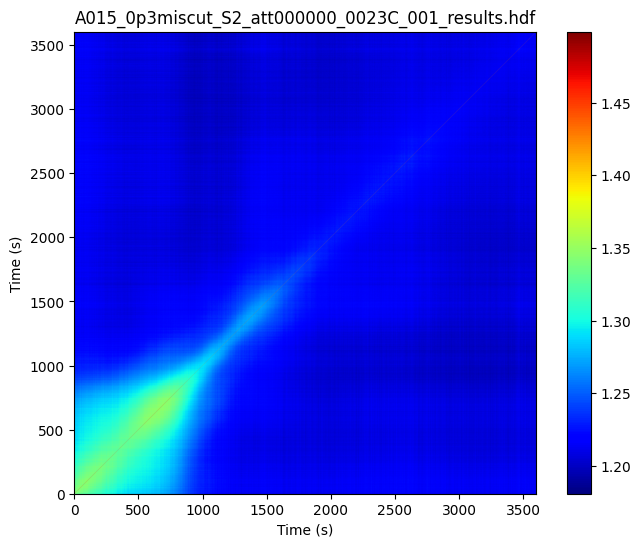

In [26]:
fname = "Twotime/A015_0p3miscut_S2_att000000_0023C_001_results.hdf"
c2, extent, t0 = read_c2_from_file(fname)
plot_c2_correlation(c2, extent, os.path.basename(fname))